In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bos_clean_data.csv")
df.head()

,Unnamed: 0,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,1.00,0.19,True,3.0,6.0,True,False,42.36413,-71.02991,...,5.00,4.96,4.85,4.88,False,1,1,0,0,0.21
1,1,1.00,1.00,True,12.0,15.0,True,True,42.32844,-71.09581,...,4.95,4.90,4.58,4.77,False,11,11,0,0,0.69
2,2,1.00,1.00,True,12.0,15.0,True,True,42.32802,-71.09387,...,4.90,4.94,4.54,4.72,False,11,11,0,0,0.72
3,3,1.00,0.37,True,8.0,32.0,True,True,42.35867,-71.06307,...,4.93,4.97,4.97,4.59,False,4,4,0,0,0.21
4,4,0.94,0.59,False,21.0,29.0,True,True,42.35173,-71.08685,...,4.56,4.00,5.00,4.67,False,12,12,0,0,0.08


In [3]:
df = df.drop(columns=["Unnamed: 0"])

bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1.00,0.19,1,3.0,6.0,1,0,42.36413,-71.02991,2,...,5.00,4.96,4.85,4.88,0,1,1,0,0,0.21
1,1.00,1.00,1,12.0,15.0,1,1,42.32844,-71.09581,2,...,4.95,4.90,4.58,4.77,0,11,11,0,0,0.69
2,1.00,1.00,1,12.0,15.0,1,1,42.32802,-71.09387,4,...,4.90,4.94,4.54,4.72,0,11,11,0,0,0.72
3,1.00,0.37,1,8.0,32.0,1,1,42.35867,-71.06307,2,...,4.93,4.97,4.97,4.59,0,4,4,0,0,0.21
4,0.94,0.59,0,21.0,29.0,1,1,42.35173,-71.08685,3,...,4.56,4.00,5.00,4.67,0,12,12,0,0,0.08


In [4]:
y = df["review_scores_rating"]
X = df.drop(columns=["review_scores_rating"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
#  Train Gradient Boosting Model

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
#  Evaluate model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.08885687766964363
RMSE: 0.1948485539122863
R2 Score: 0.7788976661273308


In [8]:
#  Feature importance

importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(importance_df.head(10))


Top Important Features:
                                         Feature  Importance
33                           review_scores_value    0.632366
28                        review_scores_accuracy    0.190124
29                     review_scores_cleanliness    0.072570
31                   review_scores_communication    0.037702
30                         review_scores_checkin    0.028217
39                             reviews_per_month    0.004606
32                        review_scores_location    0.004259
14                                minimum_nights    0.004243
20                              availability_365    0.003041
37  calculated_host_listings_count_private_rooms    0.002646


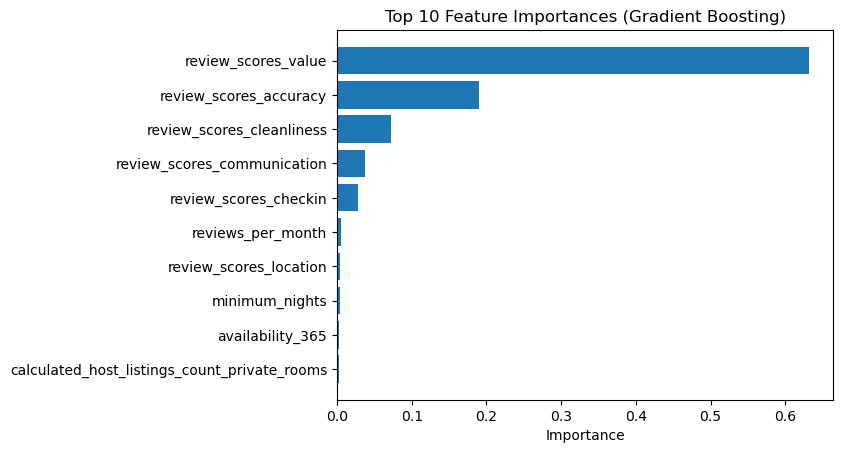

In [9]:
#  Plot feature importance

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.show()

In [11]:
df.describe()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,...,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000,4893.000000
mean,0.983098,0.936789,0.636419,31.071531,59.151236,0.987124,0.894952,47.626648,-122.334880,4.223993,...,4.885005,4.890746,4.839918,4.728786,0.301655,12.006949,9.680973,2.263029,0.034539,2.428845
std,0.090124,0.143524,0.481079,147.257068,361.093291,0.112749,0.306647,0.050140,0.034357,2.645693,...,0.229473,0.256207,0.243495,0.332246,0.459023,25.584907,23.001666,9.583673,0.498395,2.159558
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,47.498030,-122.419040,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,1.000000,0.950000,0.000000,1.000000,1.000000,1.000000,1.000000,47.599750,-122.358544,2.000000,...,4.870000,4.890000,4.800000,4.670000,0.000000,1.000000,1.000000,0.000000,0.000000,0.850000
50%,1.000000,0.990000,1.000000,3.000000,4.000000,1.000000,1.000000,47.626533,-122.333008,4.000000,...,4.950000,4.970000,4.900000,4.810000,0.000000,2.000000,2.000000,0.000000,0.000000,2.110000
75%,1.000000,1.000000,1.000000,13.000000,19.000000,1.000000,1.000000,47.664820,-122.310341,6.000000,...,5.000000,5.000000,4.970000,4.900000,1.000000,9.000000,6.000000,0.000000,0.000000,3.490000
max,1.000000,1.000000,1.000000,2989.000000,8403.000000,1.000000,1.000000,47.734010,-122.240870,16.000000,...,5.000000,5.000000,5.000000,5.000000,1.000000,138.000000,130.000000,75.000000,8.000000,60.330000


In [12]:
df['price'].max()

50039.0